Импорт необходимых библиотек

In [49]:
# Основные библиотеки для работы с данными
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Библиотеки для визуализации (пригодятся для проверки)
import matplotlib.pyplot as plt
import seaborn as sns

# Регулярные выражения для очистки текста
import re
import os
import glob

# Предупреждения
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализаций
%matplotlib inline
sns.set_style("whitegrid")

Объединение всех CSV-файлов в один DataFrame

In [51]:
# Путь к папке с сырыми данными
data_path = "../data/channels_data/processed/"

# Находим все csv-файлы в папке
all_files = glob.glob(os.path.join(data_path, "*.csv"))

# Создаем пустой список для хранения DataFrame
df_list = []

# Читаем каждый файл и добавляем в список
for filename in all_files:
    df_temp = pd.read_csv(filename)
    df_list.append(df_temp)

# Объединяем все DataFrame в один
df = pd.concat(df_list, axis=0, ignore_index=True)

# Смотрим на размер и первые строки
print(f"Размер объединенного датасета: {df.shape}")
df

Размер объединенного датасета: (10763, 85)


,channel_username,channel_title,channel_subscribers,post_id,post_date,post_time,post_datetime,scraped_at,is_scheduled,has_poll,...,reaction_🔦,reaction_🗣,reaction_💔,reaction_💩,reaction_😈,reaction_😭,reaction_🚫,reaction_🤡,reaction_🥹,reaction_😇
0,AI_point_of_view,Точка машинного зрения,2597,1813,2025-11-28,16:33:05,2025-11-28 16:33:05+00:00,2025-12-01 02:56:40.802261,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AI_point_of_view,Точка машинного зрения,2597,1809,2025-11-28,13:46:00,2025-11-28 13:46:00+00:00,2025-12-01 02:56:40.803261,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AI_point_of_view,Точка машинного зрения,2597,1808,2025-11-28,10:39:40,2025-11-28 10:39:40+00:00,2025-12-01 02:56:40.803261,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AI_point_of_view,Точка машинного зрения,2597,1805,2025-11-28,09:43:18,2025-11-28 09:43:18+00:00,2025-12-01 02:56:40.803261,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AI_point_of_view,Точка машинного зрения,2597,1804,2025-11-28,09:38:29,2025-11-28 09:38:29+00:00,2025-12-01 02:56:40.804698,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10758,tbank_education,Т-Образование,115068,2548,2024-12-02,12:30:57,2024-12-02 12:30:57+00:00,2025-12-01 02:59:27.803807,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10759,tbank_education,Т-Образование,115068,2547,2024-12-01,13:46:18,2024-12-01 13:46:18+00:00,2025-12-01 02:59:27.803807,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10760,tbank_education,Т-Образование,115068,2546,2024-12-01,13:45:52,2024-12-01 13:45:52+00:00,2025-12-01 02:59:27.803807,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10761,tbank_education,Т-Образование,115068,2545,2024-12-01,10:53:46,2024-12-01 10:53:46+00:00,2025-12-01 02:59:27.803807,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Обработка пропущенных значений (NaN)

In [52]:
# Создаем красивую таблицу с процентами пропусков
missing_data = df.isnull().sum().to_frame(name='Кол-во пропусков')
missing_data['% пропусков'] = (missing_data['Кол-во пропусков'] / len(df)) * 100
missing_data = missing_data[missing_data['Кол-во пропусков'] > 0].sort_values('Кол-во пропусков', ascending=False)

print("Столбцы с пропусками:")
missing_data

Столбцы с пропусками:


,Кол-во пропусков,% пропусков
reaction_🎃,10762,99.990709
reaction_😨,10762,99.990709
reaction_🥱,10762,99.990709
reaction_🙊,10761,99.981418
reaction_🤪,10759,99.962836
...,...,...
reaction_🤔,6005,55.792995
reaction_🔥,4293,39.886649
reaction_👍,1558,14.475518
media_type,1485,13.797268


In [53]:
# Удаляем столбцы с 100% пропусками
columns_to_drop = missing_data[missing_data['% пропусков'] == 100].index.tolist()
print(f"\nУдаляем столбцы с 100% пропусками ({len(columns_to_drop)} шт.):")
for col in columns_to_drop:
    print(f"   - {col}")

df = df.drop(columns=columns_to_drop)
print(f"Размер датасета после удаления пустых столбцов: {df.shape}")


Удаляем столбцы с 100% пропусками (0 шт.):
Размер датасета после удаления пустых столбцов: (10763, 85)


In [54]:
# Находим все колонки с реакциями (которые остались после удаления)
reaction_columns = [col for col in df.columns if col.startswith('reaction_')]
print(f"Колонок с реакциями: {len(reaction_columns)}")

# Заменяем пропуски в реакциях на 0
df[reaction_columns] = df[reaction_columns].fillna(0)

print("✅ Пропуски в реакциях заменены на 0")
df

Колонок с реакциями: 65
✅ Пропуски в реакциях заменены на 0


,channel_username,channel_title,channel_subscribers,post_id,post_date,post_time,post_datetime,scraped_at,is_scheduled,has_poll,...,reaction_🔦,reaction_🗣,reaction_💔,reaction_💩,reaction_😈,reaction_😭,reaction_🚫,reaction_🤡,reaction_🥹,reaction_😇
0,AI_point_of_view,Точка машинного зрения,2597,1813,2025-11-28,16:33:05,2025-11-28 16:33:05+00:00,2025-12-01 02:56:40.802261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AI_point_of_view,Точка машинного зрения,2597,1809,2025-11-28,13:46:00,2025-11-28 13:46:00+00:00,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AI_point_of_view,Точка машинного зрения,2597,1808,2025-11-28,10:39:40,2025-11-28 10:39:40+00:00,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AI_point_of_view,Точка машинного зрения,2597,1805,2025-11-28,09:43:18,2025-11-28 09:43:18+00:00,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AI_point_of_view,Точка машинного зрения,2597,1804,2025-11-28,09:38:29,2025-11-28 09:38:29+00:00,2025-12-01 02:56:40.804698,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10758,tbank_education,Т-Образование,115068,2548,2024-12-02,12:30:57,2024-12-02 12:30:57+00:00,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10759,tbank_education,Т-Образование,115068,2547,2024-12-01,13:46:18,2024-12-01 13:46:18+00:00,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10760,tbank_education,Т-Образование,115068,2546,2024-12-01,13:45:52,2024-12-01 13:45:52+00:00,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10761,tbank_education,Т-Образование,115068,2545,2024-12-01,10:53:46,2024-12-01 10:53:46+00:00,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
print(f"Уникальные значения media_type до обработки: {df['media_type'].unique()}")

# Заменяем пропуски на 'no_media'
df['media_type'] = df['media_type'].fillna('no_media')

print(f"Уникальные значения media_type после обработки: {df['media_type'].unique()}")

Уникальные значения media_type до обработки: ['photo' 'document' 'other' nan]
Уникальные значения media_type после обработки: ['photo' 'document' 'other' 'no_media']


In [56]:
def process_missing_text_in_dataframe(df):
    """
    Обрабатывает пропуски в тексте в объединенном датафрейме:
    1. Если пост с опросом (has_poll=True) - заменяем текст на маркер '[ОПРОС]'
    2. Если пост без текста и без опроса - удаляем строку
    3. Во всех остальных случаях оставляем как есть
    """
    # Сохраняем исходное количество строк
    original_rows = len(df)
    print(f"📊 Исходное количество постов: {original_rows:,}")
    
    # Проверяем наличие необходимых столбцов
    if 'text' not in df.columns:
        print("⚠️ Столбец 'text' не найден в датафрейме")
        return df
    
    # Создаем копию датафрейма
    df_processed = df.copy()
    
    # Определяем посты с пропущенным текстом
    # Используем astype(str) чтобы обработать и NaN и пустые строки
    missing_text_mask = (
        df_processed['text'].isna() | 
        (df_processed['text'].astype(str).str.strip() == '')
    )
    
    posts_with_missing_text = missing_text_mask.sum()
    print(f"📝 Постов без текста: {posts_with_missing_text:,}")
    
    if posts_with_missing_text == 0:
        print("✅ Нет постов с пропущенным текстом")
        return df_processed
    
    # Разделяем обработку в зависимости от наличия столбца has_poll
    if 'has_poll' in df_processed.columns:
        print("📊 Использую столбец 'has_poll' для обработки")
        
        # 1. Обрабатываем посты с опросами без текста
        polls_mask = missing_text_mask & (df_processed['has_poll'] == True)
        polls_count = polls_mask.sum()
        
        if polls_count > 0:
            print(f"✅ Обнаружено постов с опросами без текста: {polls_count:,}")
            print("   Заменяю текст на маркер '[ОПРОС]'")
            df_processed.loc[polls_mask, 'text'] = '[ОПРОС]'
        
        # 2. Удаляем посты без текста и без опросов
        non_polls_mask = missing_text_mask & (df_processed['has_poll'] != True)
        non_polls_count = non_polls_mask.sum()
        
        if non_polls_count > 0:
            print(f"❌ Удаляю посты без текста и без опросов: {non_polls_count:,}")
            df_processed = df_processed[~non_polls_mask].copy()
        
        # 3. Также проверяем, не остались ли посты с опросами где текст все еще пропущен
        # (на случай, если has_poll был NaN или другим значением)
        if polls_count > 0:
            remaining_polls = (df_processed['text'].astype(str).str.strip() == '') & (df_processed['has_poll'] == True)
            if remaining_polls.any():
                df_processed.loc[remaining_polls, 'text'] = '[ОПРОС]'
                print(f"✅ Дополнительно обработано опросов: {remaining_polls.sum():,}")
    
    else:
        # Если нет столбца has_poll, удаляем ВСЕ посты без текста
        print("⚠️ Столбец 'has_poll' не найден")
        print(f"❌ Удаляю все посты без текста: {posts_with_missing_text:,}")
        df_processed = df_processed[~missing_text_mask].copy()
    
    # Финальная статистика
    final_rows = len(df_processed)
    removed_rows = original_rows - final_rows
    
    print(f"\n📈 ИТОГОВАЯ СТАТИСТИКА:")
    print(f"  Осталось постов: {final_rows:,}")
    print(f"  Удалено постов: {removed_rows:,} ({removed_rows/original_rows*100:.1f}%)")
    
    # Проверяем, не осталось ли еще постов с пустым текстом
    remaining_empty = (df_processed['text'].astype(str).str.strip() == '').sum()
    if remaining_empty > 0:
        print(f"⚠️ Осталось постов с пустым текстом: {remaining_empty:,}")
    
    return df_processed


In [57]:
print(f"Пропусков в тексте до обработки: {df['text'].isnull().sum()}")

df = process_missing_text_in_dataframe(df)


Пропусков в тексте до обработки: 284
📊 Исходное количество постов: 10,763
📝 Постов без текста: 284
📊 Использую столбец 'has_poll' для обработки
❌ Удаляю посты без текста и без опросов: 284

📈 ИТОГОВАЯ СТАТИСТИКА:
  Осталось постов: 10,479
  Удалено постов: 284 (2.6%)



📊 АНАЛИЗ РЕЗУЛЬТАТОВ

📊 АНАЛИЗ РЕЗУЛЬТАТОВ ОБРАБОТКИ ТЕКСТА
📈 Всего постов после обработки: 10,479

📝 РАСПРЕДЕЛЕНИЕ ПО ТИПАМ ТЕКСТА:
  Посты с текстом: 10,479 (100.0%)
  Посты с опросами: 0 (0.0%)
  Пустые посты: 0 (0.0%)

🔍 ПРОВЕРКА ОПРОСОВ:
  По has_poll=True: 120
  По маркеру '[ОПРОС]': 0
⚠️ Несоответствий: 120 постов с has_poll=True но без маркера опроса

📏 АНАЛИЗ ДЛИНЫ ТЕКСТА:
  Средняя длина: 831 символов
  Медианная длина: 472 символов
  Минимальная длина: 1 символов
  Максимальная длина: 8278 символов
  Стандартное отклонение: 905 символов


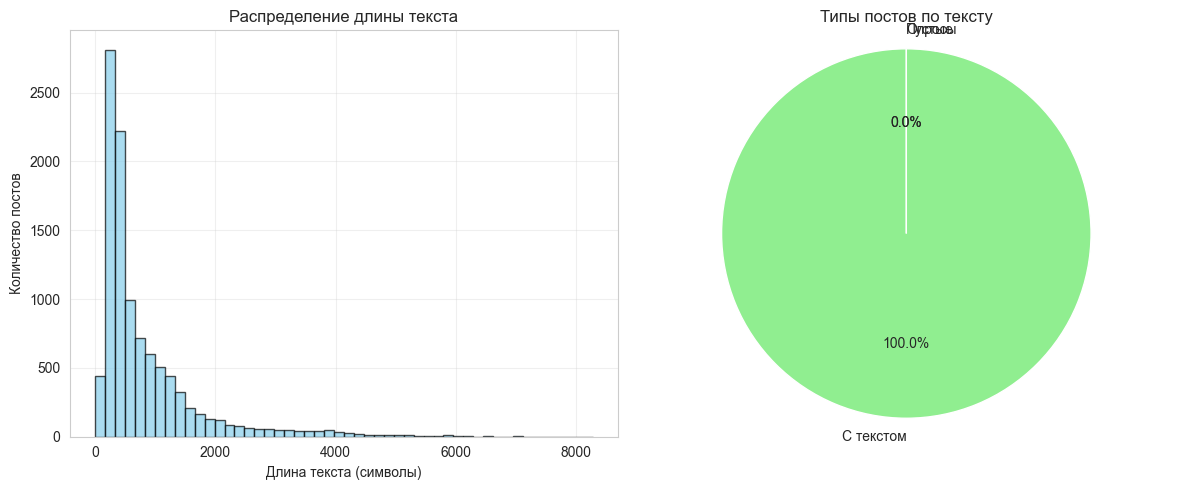

In [58]:
def analyze_text_processing_results(df):
    """
    Анализирует результаты обработки текста
    """
    print("\n📊 АНАЛИЗ РЕЗУЛЬТАТОВ ОБРАБОТКИ ТЕКСТА")
    print("="*60)
    
    if 'text' not in df.columns:
        print("❌ Столбец 'text' не найден")
        return
    
    # Общая статистика
    total_posts = len(df)
    print(f"📈 Всего постов после обработки: {total_posts:,}")
    
    # Распределение по типам текста
    text_series = df['text'].astype(str)
    
    # Посты с реальным текстом (не пустые и не маркеры опросов)
    real_text_mask = (text_series.str.strip() != '') & (text_series != '[ОПРОС]')
    real_text_count = real_text_mask.sum()
    real_text_percentage = (real_text_count / total_posts) * 100 if total_posts > 0 else 0
    
    # Посты с опросами
    poll_marker_count = (text_series == '[ОПРОС]').sum()
    poll_marker_percentage = (poll_marker_count / total_posts) * 100 if total_posts > 0 else 0
    
    # Пустые посты (если остались)
    empty_text_count = (text_series.str.strip() == '').sum()
    empty_text_percentage = (empty_text_count / total_posts) * 100 if total_posts > 0 else 0
    
    print(f"\n📝 РАСПРЕДЕЛЕНИЕ ПО ТИПАМ ТЕКСТА:")
    print(f"  Посты с текстом: {real_text_count:,} ({real_text_percentage:.1f}%)")
    print(f"  Посты с опросами: {poll_marker_count:,} ({poll_marker_percentage:.1f}%)")
    print(f"  Пустые посты: {empty_text_count:,} ({empty_text_percentage:.1f}%)")
    
    if 'has_poll' in df.columns:
        # Проверяем соответствие между has_poll и маркерами опросов
        polls_from_marker = (text_series == '[ОПРОС]').sum()
        polls_from_column = (df['has_poll'] == True).sum()
        
        print(f"\n🔍 ПРОВЕРКА ОПРОСОВ:")
        print(f"  По has_poll=True: {polls_from_column:,}")
        print(f"  По маркеру '[ОПРОС]': {polls_from_marker:,}")
        
        # Находим несоответствия
        inconsistent_polls = ((df['has_poll'] == True) & (text_series != '[ОПРОС]')).sum()
        if inconsistent_polls > 0:
            print(f"⚠️ Несоответствий: {inconsistent_polls:,} постов с has_poll=True но без маркера опроса")
    
    # Анализ длины текста
    if real_text_count > 0:
        real_text_lengths = df[real_text_mask]['text'].astype(str).apply(len)
        
        print(f"\n📏 АНАЛИЗ ДЛИНЫ ТЕКСТА:")
        print(f"  Средняя длина: {real_text_lengths.mean():.0f} символов")
        print(f"  Медианная длина: {real_text_lengths.median():.0f} символов")
        print(f"  Минимальная длина: {real_text_lengths.min():.0f} символов")
        print(f"  Максимальная длина: {real_text_lengths.max():.0f} символов")
        print(f"  Стандартное отклонение: {real_text_lengths.std():.0f} символов")
        
        # Визуализация
        import matplotlib.pyplot as plt
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Гистограмма длин текста
        ax1 = axes[0]
        ax1.hist(real_text_lengths, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        ax1.set_xlabel('Длина текста (символы)')
        ax1.set_ylabel('Количество постов')
        ax1.set_title('Распределение длины текста')
        ax1.grid(True, alpha=0.3)
        
        # Круговой график типов постов
        ax2 = axes[1]
        labels = ['С текстом', 'Опросы', 'Пустые']
        sizes = [real_text_count, poll_marker_count, empty_text_count]
        colors = ['lightgreen', 'lightcoral', 'lightgray']
        
        ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
        ax2.set_title('Типы постов по тексту')
        ax2.axis('equal')
        
        plt.tight_layout()
        plt.show()
    
    return {
        'total_posts': total_posts,
        'real_text_count': real_text_count,
        'poll_marker_count': poll_marker_count,
        'empty_text_count': empty_text_count,
        'real_text_percentage': real_text_percentage,
        'poll_marker_percentage': poll_marker_percentage,
        'empty_text_percentage': empty_text_percentage
    }



# 2. Анализируем результаты
print("\n📊 АНАЛИЗ РЕЗУЛЬТАТОВ")
results = analyze_text_processing_results(df)

# 3. Дополнительная очистка (опционально)
if 'text' in df.columns:
    # Удаляем лишние пробелы
    df['text'] = df['text'].astype(str).str.strip()
    # Заменяем множественные пробелы на один
    df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True)

In [ ]:
def detect_scheduled_by_seconds(df):
    """
    Определяет отложенные посты по секундам: если секунды = 00, то пост отложенный
    """
    print("🔍 ОПРЕДЕЛЕНИЕ ОТЛОЖЕННЫХ ПОСТОВ ПО СЕКУНДАМ")
    print("="*50)
    
    # Ищем столбец с временем
    time_col = None
    for col in ['post_datetime', 'post_time']:
        if col in df.columns:
            time_col = col
            break
    
    if not time_col:
        print("❌ Столбцы с временем не найдены")
        return df
    
    print(f"📅 Использую столбец: {time_col}")
    
    # Преобразуем в datetime
    if df[time_col].dtype == 'object':
        df[time_col] = pd.to_datetime(df[time_col])
    
    # Извлекаем секунды
    df['seconds'] = df[time_col].dt.second
    
    # Определяем отложенные посты (секунды = 00)
    df['is_scheduled_by_seconds'] = df['seconds'] == 0
    
    # Статистика
    total_posts = len(df)
    scheduled_by_seconds = df['is_scheduled_by_seconds'].sum()
    scheduled_percentage = scheduled_by_seconds / total_posts * 100
    
    print(f"\n📊 СТАТИСТИКА:")
    print(f"  Всего постов: {total_posts:,}")
    print(f"  Отложенные (секунды=00): {scheduled_by_seconds:,} ({scheduled_percentage:.1f}%)")
    
    # Распределение по секундам
    print(f"\n📊 РАСПРЕДЕЛЕНИЕ ПО СЕКУНДАМ:")
    second_counts = df['seconds'].value_counts().sort_index()
    
    for second in range(0, 60, 5):  # Показываем каждые 5 секунд
        if second in second_counts.index:
            count = second_counts[second]
            percentage = count / total_posts * 100
            marker = " ← отложенный" if second == 0 else ""
            print(f"  {second:02d} сек: {count:6,} ({percentage:5.1f}%){marker}")
    
    # Сравнение с существующим is_scheduled если есть
    if 'is_scheduled' in df.columns:
        print(f"\n📊 СРАВНЕНИЕ С СУЩЕСТВУЮЩИМ is_scheduled:")
        
        # Конвертируем существующий в bool
        if df['is_scheduled'].dtype == 'object':
            df['is_scheduled_bool'] = df['is_scheduled'].astype(str).str.lower().isin(['true', '1', 'yes'])
        else:
            df['is_scheduled_bool'] = df['is_scheduled'].astype(bool)
        
        existing_scheduled = df['is_scheduled_bool'].sum()
        match = (df['is_scheduled_bool'] == df['is_scheduled_by_seconds']).sum()
        match_percentage = match / total_posts * 100
        
        print(f"  • По колонке is_scheduled: {existing_scheduled:,}")
        print(f"  • По секундам=00: {scheduled_by_seconds:,}")
        print(f"  • Совпадение: {match:,} ({match_percentage:.1f}%)")
        
        # Где отличаются
        different = df[df['is_scheduled_bool'] != df['is_scheduled_by_seconds']]
        if len(different) > 0:
            print(f"\n⚠️  РАСХОЖДЕНИЯ:")
            print(f"  • Отмечен как отложенный, но секунды ≠ 00: {len(different[different['is_scheduled_bool'] == True]):,}")
            print(f"  • Не отмечен как отложенный, но секунды = 00: {len(different[different['is_scheduled_bool'] == False]):,}")
    
    # Простая визуализация
    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Гистограмма секунд
    ax1.hist(df['seconds'], bins=60, range=(0, 60), alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Секунды=00 (отложенные)')
    ax1.set_xlabel('Секунды')
    ax1.set_ylabel('Количество постов')
    ax1.set_title('Распределение по секундам публикации')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Доля отложенных постов
    labels = ['Отложенные\n(секунды=00)', 'Не отложенные\n(секунды≠00)']
    sizes = [scheduled_by_seconds, total_posts - scheduled_by_seconds]
    colors = ['lightcoral', 'lightblue']
    
    ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Доля отложенных постов')
    ax2.axis('equal')
    
    plt.tight_layout()
    plt.show()
    
    # Обновляем или создаем итоговый столбец
    print(f"\n💡 РЕКОМЕНДАЦИЯ:")
    if 'is_scheduled' in df.columns and 'is_scheduled_bool' in df.columns:
        accuracy = match_percentage
        if accuracy > 80:
            print(f"✅ Высокая точность ({accuracy:.1f}%). Обновляю is_scheduled на основе секунд")
            df['is_scheduled'] = df['is_scheduled_by_seconds']
        else:
            print(f"⚠️  Низкая точность ({accuracy:.1f}%). Создаю новый столбец is_scheduled_seconds")
            df['is_scheduled_seconds'] = df['is_scheduled_by_seconds']
    else:
        print(f"✅ Создаю столбец is_scheduled на основе секунд")
        df['is_scheduled'] = df['is_scheduled_by_seconds']
    
    # Удаляем временные столбцы
    df = df.drop(columns=['seconds', 'is_scheduled_by_seconds'], errors='ignore')
    if 'is_scheduled_bool' in df.columns:
        df = df.drop(columns=['is_scheduled_bool'], errors='ignore')
    
    return df

# Простейшая версия (1 строка для применения)
def simple_scheduled_by_seconds(df):
    """Самая простая версия: создаем is_scheduled если секунды = 00"""
    # Ищем столбец с временем
    for col in ['post_datetime', 'post_time']:
        if col in df.columns:
            time_col = col
            break
    else:
        return df
    
    # Преобразуем и определяем
    if df[time_col].dtype == 'object':
        df[time_col] = pd.to_datetime(df[time_col])
    
    df['is_scheduled'] = df[time_col].dt.second == 0
    return df

# Использование:
print("🎯 ОПРЕДЕЛЯЕМ ОТЛОЖЕННЫЕ ПОСТЫ (секунды=00)")
df = detect_scheduled_by_seconds(df)

# Или для быстрого применения без анализа:
# df = simple_scheduled_by_seconds(df)

In [ ]:
def fix_time_simple(df):
    """
    Просто добавляет 3 часа ко времени
    """
    # 1. Исправляем post_datetime (UTC+00:00 → MSK+03:00)
    if 'post_datetime' in df.columns:
        # Конвертируем в datetime с учетом UTC
        df['post_datetime'] = pd.to_datetime(df['post_datetime'], utc=True)
        # Добавляем 3 часа для московского времени
        df['post_datetime'] = df['post_datetime'] + pd.Timedelta(hours=3)
        # Убираем временную зону для удобства
        df['post_datetime'] = df['post_datetime'].dt.tz_localize(None)
    
    # 2. Обновляем post_time если он есть отдельно
    if 'post_time' in df.columns:
        # Берем время из post_datetime
        df['post_time'] = df['post_datetime'].dt.time.astype(str)
    
    # 3. Обновляем post_date если он есть отдельно  
    if 'post_date' in df.columns:
        df['post_date'] = df['post_datetime'].dt.date.astype(str)
    
    return df

df = fix_time_simple(df)
df

In [ ]:
df_drop = df.drop(columns=['scraped_at'])

In [ ]:
df_drop

In [ ]:
# Сохраняем очищенный датасет
output_path = "../data/final/cleaned_ai_publics_dataset_DROPPED.csv"

df_drop.to_csv(output_path, index=False, encoding='utf-8-sig')

In [68]:
df = pd.read_csv('../data/final/ai_publics_dataset.csv', encoding='utf-8')

df

,channel_username,channel_title,channel_subscribers,post_id,post_date,post_time,post_datetime,scraped_at,is_scheduled,has_poll,...,reaction_🔦,reaction_🗣,reaction_💔,reaction_💩,reaction_😈,reaction_😭,reaction_🚫,reaction_🤡,reaction_🥹,reaction_😇
0,AI_point_of_view,Точка машинного зрения,2597,1813,2025-11-28,19:33:05,2025-11-28 19:33:05,2025-12-01 02:56:40.802261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AI_point_of_view,Точка машинного зрения,2597,1809,2025-11-28,16:46:00,2025-11-28 16:46:00,2025-12-01 02:56:40.803261,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AI_point_of_view,Точка машинного зрения,2597,1808,2025-11-28,13:39:40,2025-11-28 13:39:40,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AI_point_of_view,Точка машинного зрения,2597,1805,2025-11-28,12:43:18,2025-11-28 12:43:18,2025-12-01 02:56:40.803261,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AI_point_of_view,Точка машинного зрения,2597,1804,2025-11-28,12:38:29,2025-11-28 12:38:29,2025-12-01 02:56:40.804698,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10474,tbank_education,Т-Образование,115068,2549,2024-12-03,18:00:00,2024-12-03 18:00:00,2025-12-01 02:59:27.803807,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10475,tbank_education,Т-Образование,115068,2548,2024-12-02,15:30:57,2024-12-02 15:30:57,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10476,tbank_education,Т-Образование,115068,2546,2024-12-01,16:45:52,2024-12-01 16:45:52,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10477,tbank_education,Т-Образование,115068,2545,2024-12-01,13:53:46,2024-12-01 13:53:46,2025-12-01 02:59:27.803807,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Карта соответствия кастомных реакций обычным эмодзи
REACTION_MAP = {
    'reaction_custom_5370610867094166617': 'reaction_🎃',  # кастомная → 🎃
    'reaction_custom_5357314052072692864': 'reaction_🤖',
    # Добавьте другие соответствия если нужно
}

def merge_mapped_reactions(df, reaction_map):
    """
    Объединяет кастомные реакции с обычными эмодзи по карте соответствия
    """
    print("🔄 Объединение реакций по карте соответствия")
    
    merged_count = 0
    
    for custom_col, emoji_col in reaction_map.items():
        # Проверяем, существуют ли оба столбца
        if custom_col in df.columns and emoji_col in df.columns:
            print(f"  • {custom_col} → {emoji_col}")
            
            # Суммируем значения
            df[emoji_col] = df[[emoji_col, custom_col]].sum(axis=1, skipna=True)
            
            # Удаляем кастомный столбец
            df = df.drop(columns=[custom_col])
            merged_count += 1
    
    if merged_count == 0:
        print("✅ Нет столбцов для объединения по карте")
    else:
        print(f"✅ Объединено {merged_count} пар реакций")
    
    return df

# Использование:
df = merge_mapped_reactions(df, REACTION_MAP)

In [ ]:
df_drop = df.drop(columns=['scraped_at'])

In [ ]:
# Сохраняем очищенный датасет
output_path = "../data/final/cleaned_ai_publics_datasetDROP.csv"

df_drop.to_csv(output_path, index=False, encoding='utf-8-sig')

In [ ]:
# День недели (0 - понедельник, 6 - воскресенье)
df['post_day_of_week'] = df['post_datetime'].dt.dayofweek

# Час публикации
df['post_hour'] = df['post_datetime'].dt.hour

# Выходной день (1 - да, 0 - нет)
df['is_weekend'] = (df['post_day_of_week'] >= 5).astype(int)

# Часть дня (Утро, День, Вечер, Ночь)
bins = [-1, 6, 12, 18, 23]
labels = ['Ночь', 'Утро', 'День', 'Вечер']
df['time_of_day'] = pd.cut(df['post_hour'], bins=bins, labels=labels)

In [ ]:
# Длина текста (в символах) - у вас уже есть text_length, но на всякий случай
df['text_length_chars'] = df['text'].apply(len)

# Длина текста в словах
df['text_length_words'] = df['text'].apply(lambda x: len(str(x).split()))

# Наличие вопроса в тексте
df['has_question'] = df['text'].str.contains(r'\?', na=False).astype(int)

# Наличие восклицания в тексте
df['has_exclamation'] = df['text'].str.contains(r'!', na=False).astype(int)

# Количество хештегов
df['hashtags_count'] = df['text'].str.count(r'#\w+')

# Количество упоминаний
df['mentions_count'] = df['text'].str.count(r'@\w+')

In [ ]:
# Упрощенная категоризация медиа-типов (адаптируйте под ваши данные)
media_mapping = {
    'no_media': 'none',
    'photo': 'image',
    'video': 'video',
    'gif': 'video',
    'voice': 'audio',
    'audio': 'audio',
    'video_note': 'video',
    # Добавьте другие типы, которые есть в ваших данных
}
df['media_category'] = df['media_type'].map(media_mapping).fillna('other')

# Создаем dummy-переменные для категорий медиа
media_dummies = pd.get_dummies(df['media_category'], prefix='media')
df = pd.concat([df, media_dummies], axis=1)

In [ ]:
# Основная метрика успеха: Engagement Rate (ER)
# ER = (Все реакции + репосты) / Просмотры
df['engagement_rate'] = (df['total_reactions'] + df['forwards']) / df['views']

# Защита от деления на ноль и аномалий
df['engagement_rate'] = df['engagement_rate'].replace([np.inf, -np.inf], 0)
df['engagement_rate'] = df['engagement_rate'].fillna(0)

# Дополнительные бинарные метрики успеха (можно использовать как целевые)
# "Вирусный" пост (например, выше 90% перцентиля по ER)
er_threshold = df['engagement_rate'].quantile(0.9)
df['is_viral'] = (df['engagement_rate'] >= er_threshold).astype(int)

# Пост с высоким охватом (аналогично, по просмотрам)
views_threshold = df['views'].quantile(0.9)
df['is_high_reach'] = (df['views'] >= views_threshold).astype(int)

In [ ]:
# Визуализируем распределение ключевых числовых признаков
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df['views'].plot(kind='box', ax=axes[0,0], title='Views')
df['total_reactions'].plot(kind='box', ax=axes[0,1], title='Total Reactions')
df['engagement_rate'].plot(kind='box', ax=axes[1,0], title='Engagement Rate')
df['text_length_words'].plot(kind='box', ax=axes[1,1], title='Text Length (words)')

plt.tight_layout()
plt.show()

# Обработка выбросов: например, winsorization или удаление экстремальных значений
# Вариант 1: Winsorization (ограничение выбросов)
from scipy.stats.mstats import winsorize

df['views_winsorized'] = winsorize(df['views'], limits=[0.01, 0.01])
df['engagement_rate_winsorized'] = winsorize(df['engagement_rate'], limits=[0.05, 0.05])

# Вариант 2: Удаление экстремальных выбросов (например, 99% перцентиль)
Q1 = df['engagement_rate'].quantile(0.01)
Q99 = df['engagement_rate'].quantile(0.99)
df = df[(df['engagement_rate'] >= Q1) & (df['engagement_rate'] <= Q99)]

print(f"Размер датасета после обработки выбросов: {df.shape}")

In [ ]:
# Посмотрим на итоговую информацию
print("=== ИТОГОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ ===")
print(f"Размер: {df.shape}")
print(f"Период данных: от {df['post_datetime'].min()} до {df['post_datetime'].max()}")
print(f"Количество уникальных каналов: {df['channel_username'].nunique()}")

# Проверим несколько случайных постов
pd.set_option('display.max_columns', None)
df.sample(3).T  # Транспонируем для удобства просмотра

In [ ]:
# Сохраняем очищенный датасет
output_path = "../data/final/cleaned_ai_publics_dataset_feature_engineering.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')  # utf-8-sig для корректного отображения кириллицы в Excel

print(f"Очищенный датасет сохранен в: {output_path}")